In [1]:
import os 
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import csv, random
import time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [3]:
def load_png_as_rgb(png_path):
    with Image.open(png_path) as img:
        img = img.convert("RGB")
        arr = np.array(img, dtype = np.uint8)

    assert arr.ndim == 3 and arr.shape[2] == 3
    assert arr.dtype == np.uint8
    return arr

In [4]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

In [5]:
sam2_checkpoint = "/home/predm/sam2/checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

In [6]:
sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

In [68]:
mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=64,
    points_per_batch=128,
    pred_iou_thresh=0.6,
    stability_score_thresh=0.92,
    stability_score_offset=0.6,
    crop_n_layers=1,
    box_nms_thresh=0.8,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=50.0,
    use_m2m=True,
)

In [19]:
with open("/home/predm/skimage_segmentation/paired.csv", newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

idxs = sorted(random.sample(range(len(rows)), k=min(10, len(rows))))
idxs

[0, 3, 15, 19, 48, 55, 56, 77, 85, 104]

In [69]:
i = idxs[6]
png_path = rows[i]["png_path"].strip()
npz_path = rows[i]["npz_path"].strip()

image = load_png_as_rgb(png_path)

data = np.load(npz_path)
ice_mask = data["ice_mask"]          
labels = data["labels"]  

t0 = time.perf_counter()
masks = mask_generator_2.generate(image)
t_generate = time.perf_counter() - t0

print("masks:", len(masks))
print("keys:", masks[0].keys())
print("ice_mask unique:", np.unique(ice_mask))
print("ice pixels:", (~ice_mask).sum())
print("water pixels:", ice_mask.sum())
print("generate time:", t_generate)

masks: 28
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 116190
water pixels: 145954
generate time: 248.74176434099945


In [70]:
def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

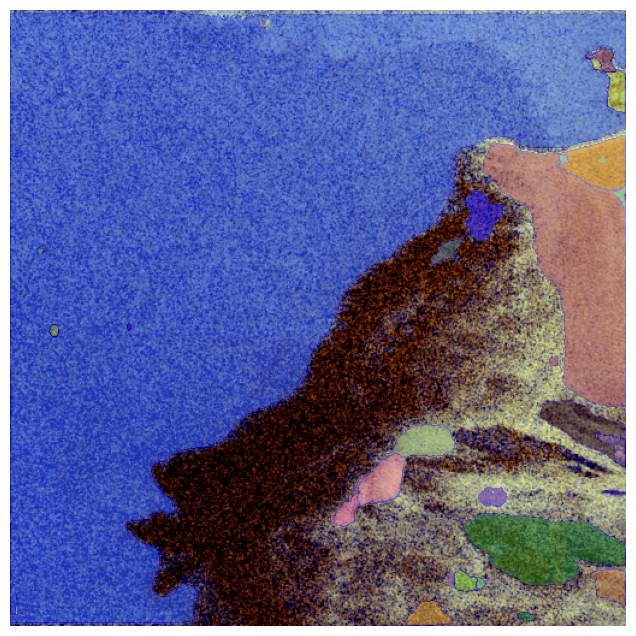

In [71]:
plt.figure(figsize=(8, 8))
plt.imshow(image)
show_anns(masks)
plt.axis("off")
plt.show()

In [72]:
H, W = ice_mask.shape
sam2_pred = np.full((H, W), -1, dtype = np.int8)
masks_sorted = sorted(masks, key=lambda x: x["predicted_iou"], reverse=True)

In [88]:
water_mask = ice_mask.astype(bool)

for ann in masks_sorted:
    m = ann["segmentation"]
    if m.sum() == 0:
        continue

    mm = m & (sam2_pred == -1)
    if mm.sum() == 0:
        continue
        
    water_fraction = water_mask[mm].mean()
    sam2_pred[mm] = 1 if water_fraction > 0.5 else 0


coverage = (sam2_pred != -1).mean()

union = np.zeros((H, W), dtype=bool)
for ann in masks:
    union |= ann["segmentation"]
coverage_union = union.mean()

pred_water = (sam2_pred == 1).sum()
pred_ice   = (sam2_pred == 0).sum()
pred_unk   = (sam2_pred == -1).sum()

print("Coverage:", float(coverage))
print("union coverage:", float(coverage_union))
print(
    f"Pred water: {int(pred_water)}\n"
    f"Pred ice: {int(pred_ice)}\n"
    f"Unclassified: {int(pred_unk)}"
)

ious = np.array([a["predicted_iou"] for a in masks])
stabs = np.array([a["stability_score"] for a in masks])
print(f"pred_iou: min {float(ious.min())} mean {float(ious.mean())} max {float(ious.max())}")
print(f"pred_iou: min {float(stabs.min())} mean {float(stabs.mean())} max {float(stabs.max())}")

Coverage: 0.671783447265625
union coverage: 0.671783447265625
Pred water: 146059
Pred ice: 30045
Unclassified: 86040
pred_iou: min 0.7354967594146729 mean 0.8676135625158038 max 0.9884236454963684
pred_iou: min 0.9207459092140198 mean 0.9381450010197503 max 0.9750000238418579


In [87]:
def iou_binary(pred_bool, gt_bool):
    inter = np.logical_and(pred_bool, gt_bool).sum()
    uni   = np.logical_or(pred_bool, gt_bool).sum()
    return inter / uni if uni > 0 else float("nan")

valid = (sam2_pred != -1)

iou_water_cov  = iou_binary((sam2_pred == 1) & valid, (ice_mask == True) & valid)
iou_water_full = iou_binary((sam2_pred == 1),(ice_mask == True))

iou_ice_cov  = iou_binary((sam2_pred == 0) & valid, (ice_mask == False) & valid)
iou_ice_full = iou_binary((sam2_pred == 0),(ice_mask == False))

print("IoU water (covered):", iou_water_cov)
print("IoU water (full):   ", iou_water_full)
print("IoU ice (covered):  ", iou_ice_cov)
print("IoU ice (full):     ", iou_ice_full)

IoU water (covered): 0.9752661304124594
IoU water (full):    0.9525981103436286
IoU ice (covered):   0.892604482492123
IoU ice (full):      0.2584117859663012


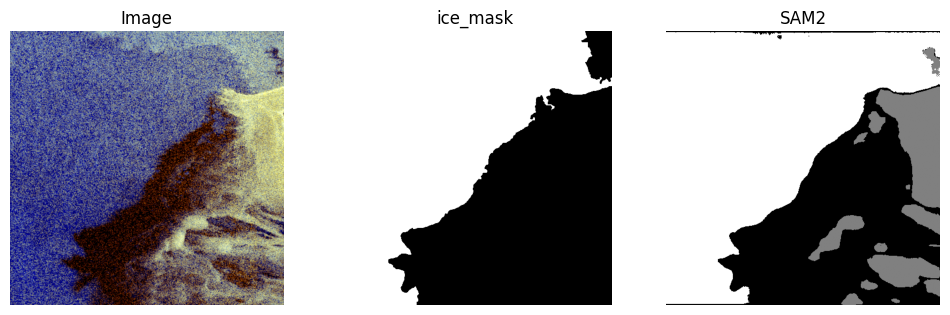

In [75]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(ice_mask, cmap="gray")
plt.title("ice_mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sam2_pred, cmap="gray", vmin=-1, vmax=1)
plt.title("SAM2")
plt.axis("off")

plt.show()

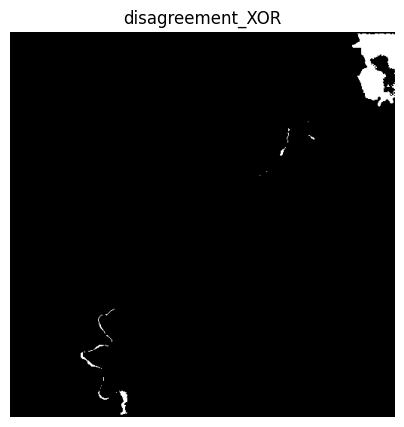

In [76]:
errors = (sam2_pred != ice_mask.astype(np.int8)) & valid
plt.figure(figsize=(5,5))
plt.imshow(errors, cmap="gray")
plt.title("disagreement_XOR")
plt.axis("off")
plt.show()

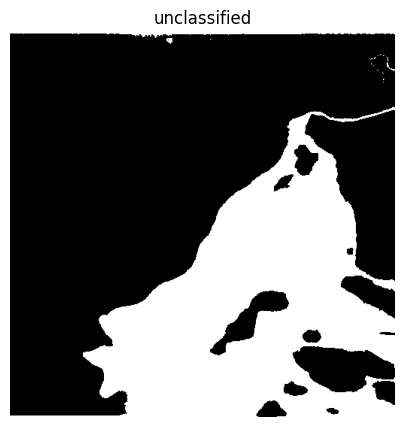

In [78]:
unseg = (sam2_pred == -1)
plt.figure(figsize=(5,5))
plt.imshow(unseg, cmap="gray")
plt.title("unclassified")
plt.axis("off")
plt.show()